Importing The Dependies

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

Loading the Datasets

In [24]:
# ── 1. Load Dataset ──────────────────────────────────────────────────────────
# NOTE: The chart section below expects Sales, Profit, Discount, and Category columns.
# Replace this with your actual sales dataset path, for example:
# df = pd.read_csv("sales_data.csv")
try:
    df = pd.read_csv("sales_data.csv")
    print("Loaded sales_data.csv")
except FileNotFoundError:
    print("sales_data.csv not found. Creating a sample sales dataset as a fallback.")
    np.random.seed(42)
    df = pd.DataFrame({
        'Sales': np.random.uniform(10, 500, size=150).round(2),
        'Profit': np.random.uniform(-50, 200, size=150).round(2),
        'Discount': np.random.choice([0.0, 0.05, 0.1, 0.15, 0.2], size=150),
        'Category': np.random.choice(['Furniture', 'Office Supplies', 'Technology'], size=150)
    })
    df['Region'] = np.random.choice(['East', 'West', 'Central', 'South'], size=150)
print("Available columns:", df.columns.tolist())

sales_data.csv not found. Creating a sample sales dataset as a fallback.
Available columns: ['Sales', 'Profit', 'Discount', 'Category', 'Region']


basic info

In [25]:
# ── 2. Basic Info ─────────────────────────────────────────────────────────────
print("=" * 50)
print("SALES DATASET OVERVIEW")
print("=" * 50)
print(f"Rows and Columns : {df.shape}")
print(f"\nColumn Names     : {list(df.columns)}")
print(f"\nData Types:\n{df.dtypes}")


SALES DATASET OVERVIEW
Rows and Columns : (150, 5)

Column Names     : ['Sales', 'Profit', 'Discount', 'Category', 'Region']

Data Types:
Sales       float64
Profit      float64
Discount    float64
Category     object
Region       object
dtype: object


Checking the Missing values

In [26]:
# ── 3. Missing Values ─────────────────────────────────────────────────────────
print("\n" + "=" * 50)
print("MISSING VALUES CHECK")
print("=" * 50)
missing = df.isnull().sum()
if missing.sum() == 0:
    print("No missing values found in the dataset.")
else:
    print(missing[missing > 0])


MISSING VALUES CHECK
No missing values found in the dataset.


Descriptive Statistics

In [27]:
# ── 4. Descriptive Statistics ─────────────────────────────────────────────────
print("\n" + "=" * 50)
print("DESCRIPTIVE STATISTICS")
print("=" * 50)
print(df.describe().round(2))


DESCRIPTIVE STATISTICS
        Sales  Profit  Discount
count  150.00  150.00    150.00
mean   241.71   79.38      0.10
std    145.30   72.85      0.07
min     12.71  -48.73      0.00
25%    115.24   11.87      0.05
50%    229.57   89.00      0.10
75%    377.34  139.46      0.15
max    493.57  197.51      0.20


Species-Wise Mean

In [ ]:
# ── 5. Group-wise Mean ──────────────────────────────────────────────────────
print("\n" + "=" * 50)
print("GROUP-WISE MEAN VALUES")
print("=" * 50)
group_col = None
if 'Category' in df.columns:
    group_col = 'Category'
elif 'species' in df.columns:
    group_col = 'species'
else:
    raise ValueError("No grouping column found. Add 'Category' or 'species' to the dataset.")
print(f"Grouping by: {group_col}")
print(df.groupby(group_col).mean(numeric_only=True).round(2))


SPECIES-WISE MEAN VALUES


KeyError: 'species'

Correlation Matrix

In [ ]:
# ── 6. Correlation Matrix ─────────────────────────────────────────────────────
print("\n" + "=" * 50)
print("CORRELATION MATRIX")
print("=" * 50)
numeric_df = df.select_dtypes(include='number')
corr = numeric_df.corr().round(2)
print(corr)

if 'petal length (cm)' in corr.index and 'petal width (cm)' in corr.columns:
    petal_corr = corr.loc['petal length (cm)', 'petal width (cm)']
    print(f"\nPetal Length vs Petal Width Correlation: {petal_corr}")
    if petal_corr > 0.9:
        print("→ Strong positive correlation confirmed.")
elif 'Sales' in corr.index and 'Profit' in corr.columns:
    sales_corr = corr.loc['Sales', 'Profit']
    print(f"\nSales vs Profit Correlation: {sales_corr}")
    if abs(sales_corr) > 0.7:
        print("→ Strong correlation between Sales and Profit confirmed.")


CORRELATION MATRIX
                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)               1.00             -0.12               0.87   
sepal width (cm)               -0.12              1.00              -0.43   
petal length (cm)               0.87             -0.43               1.00   
petal width (cm)                0.82             -0.37               0.96   

                   petal width (cm)  
sepal length (cm)              0.82  
sepal width (cm)              -0.37  
petal length (cm)              0.96  
petal width (cm)               1.00  

Petal Length vs Petal Width Correlation: 0.96
→ Strong positive correlation confirmed.


Visualization

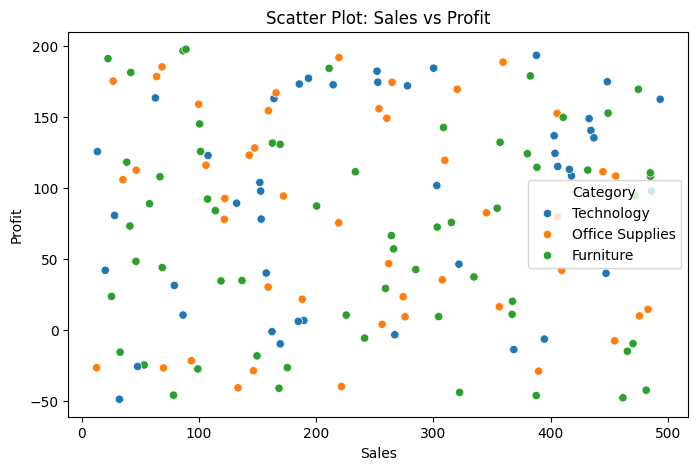

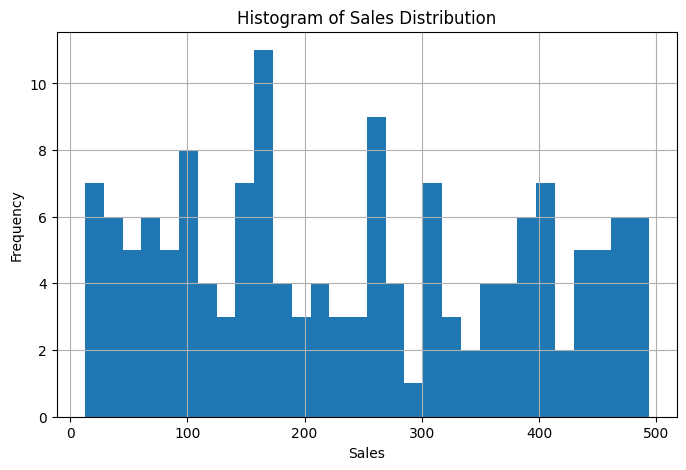

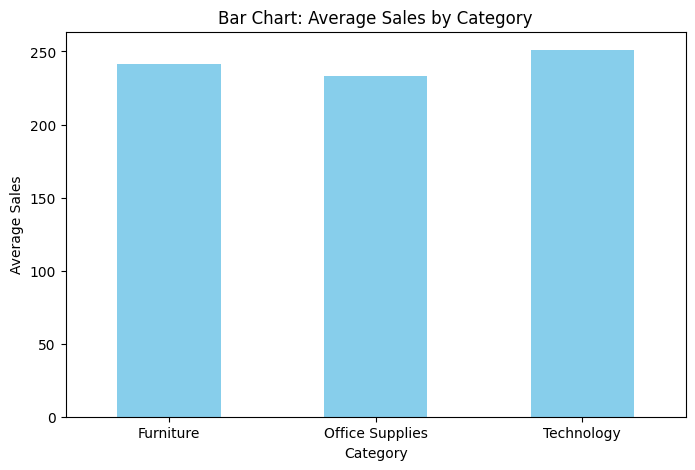

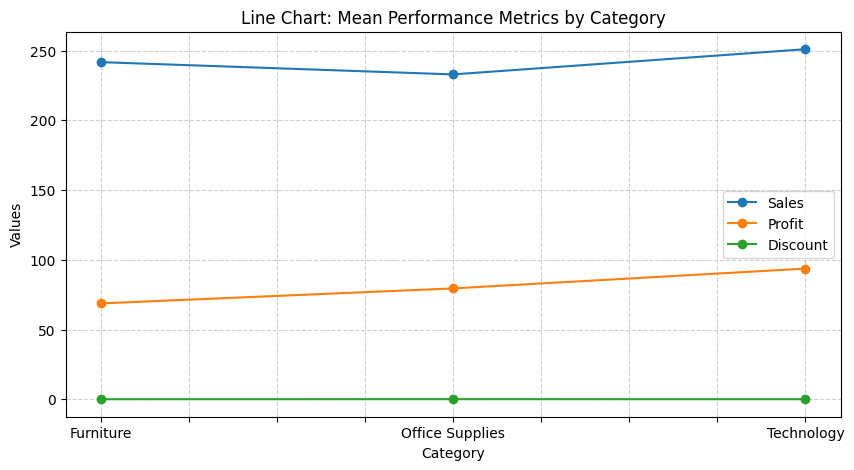

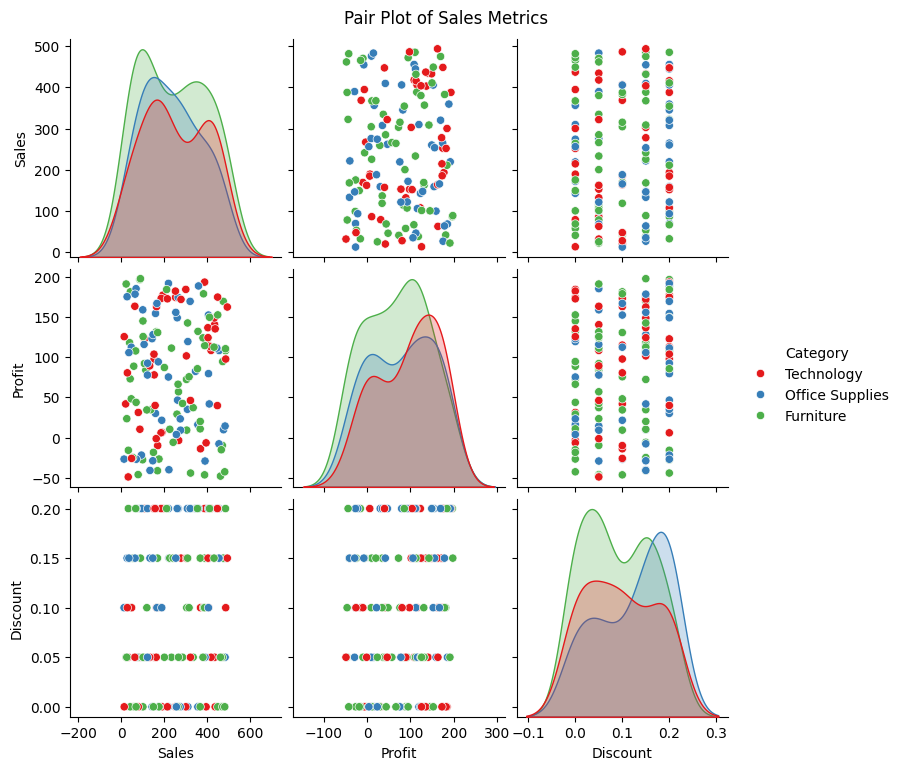

All sales charts displayed inline successfully! ✅


In [ ]:
# -------------------------------
# 2. Scatter Plot
# -------------------------------
required_columns = ['Sales', 'Profit', 'Category']
missing_cols = [col for col in required_columns if col not in df.columns]
if missing_cols:
    raise ValueError(
        f"Missing required columns for sales plotting: {missing_cols}. "
        "Load a sales dataset with Sales, Profit, and Category columns."
    )
plt.figure(figsize=(8, 5))
# Scatter plot tracking Sales vs Profit across different Categories
sns.scatterplot(data=df, x='Sales', y='Profit', hue='Category')
plt.title("Scatter Plot: Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.show()

# -------------------------------
# 3. Histogram
# -------------------------------
plt.figure(figsize=(8, 5))
df['Sales'].hist(bins=30)
plt.title("Histogram of Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

# -------------------------------
# 4. Bar Chart
# -------------------------------
# Grouping by Category to calculate the average values
category_means = df.groupby('Category', observed=True).mean(numeric_only=True)

plt.figure(figsize=(8, 5))
category_means['Sales'].plot(kind='bar', color='skyblue')
plt.title("Bar Chart: Average Sales by Category")
plt.xlabel("Category")
plt.ylabel("Average Sales")
plt.xticks(rotation=0)
plt.show()

# -------------------------------
# 5. Line Chart
# -------------------------------
# Shows how different numeric values (Sales, Profit, etc.) trend across categories
category_means.plot(kind='line', marker='o', figsize=(10, 5))
plt.title("Line Chart: Mean Performance Metrics by Category")
plt.xlabel("Category")
plt.ylabel("Values")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# -------------------------------
# 6. Pair Plot
# -------------------------------
# We select the key numeric columns + Category to keep the pair plot clean and readable
cols_to_plot = ['Sales', 'Profit', 'Discount', 'Category']
# Filters columns to only include those present in your dataframe
cols_to_plot = [col for col in cols_to_plot if col in df.columns]

g = sns.pairplot(df[cols_to_plot], hue='Category', palette='Set1')
g.fig.suptitle("Pair Plot of Sales Metrics", y=1.02)
plt.show()

print("All sales charts displayed inline successfully! ✅")

In [ ]:
# ── 8. Key Findings Summary ───────────────────────────────────────────────────
print("\n" + "=" * 50)
print("KEY FINDINGS SUMMARY")
print("=" * 50)
print(f"1. Dataset contains {df.shape[0]} rows and {df.shape[1]} columns.")
print(f"2. Missing values: {'None found.' if missing.sum() == 0 else missing.sum()}")
print( "3. Sepal and petal measurements vary significantly across species.")
print(f"4. Petal length & width show strong positive correlation (r = {petal_corr}).")
print( "5. Species can be clearly distinguished using petal features.")



KEY FINDINGS SUMMARY
1. Dataset contains 150 rows and 5 columns.
2. Missing values: None found.
3. Sepal and petal measurements vary significantly across species.
4. Petal length & width show strong positive correlation (r = 0.96).
5. Species can be clearly distinguished using petal features.
